In [ ]:
# !pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)



TensorFlow Version: 2.20.0


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print("Dataset Location:", data_dir)


Dataset Location: /root/.keras/datasets/flower_photos


In [ ]:
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Adjust data_dir to point to the actual folder containing class subdirectories
# This assumes the 'flower_photos.tgz' extracts to a 'flower_photos' folder inside data_dir
data_dir_path = os.path.join(data_dir, 'flower_photos')

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


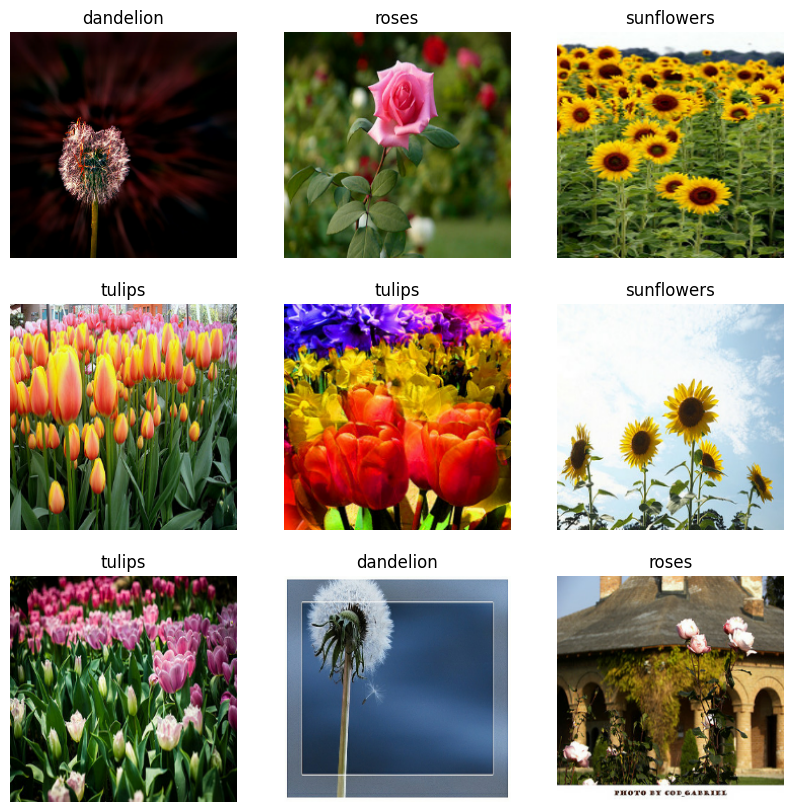

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 60s 321ms/step - accuracy: 0.7837 - loss: 0.6152 - val_accuracy: 0.5150 - val_loss: 7.3546
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 278ms/step - accuracy: 0.8467 - loss: 0.4473 - val_accuracy: 0.4482 - val_loss: 8.6699
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 282ms/step - accuracy: 0.8730 - loss: 0.3691 - val_accuracy: 0.4823 - val_loss: 8.2050
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 281ms/step - accuracy: 0.8818 - loss: 0.3380 - val_accuracy: 0.6676 - val_loss: 3.0245
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.8924 - loss: 0.3116 - val_accuracy: 0.5341 - val_loss: 6.9855
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.9009 - loss: 0.2894 - val_accuracy: 0.3460 - val_loss: 12.7093
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 281ms/step - accuracy: 0.9142 - loss: 0.2371 - val_accuracy: 0.3815 - val_loss: 15.4387
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 285ms/step - accuracy: 0.9261 - loss: 0.2244 - val_ac

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6172 - loss: 4.1461
Validation Accuracy: 0.6171662211418152


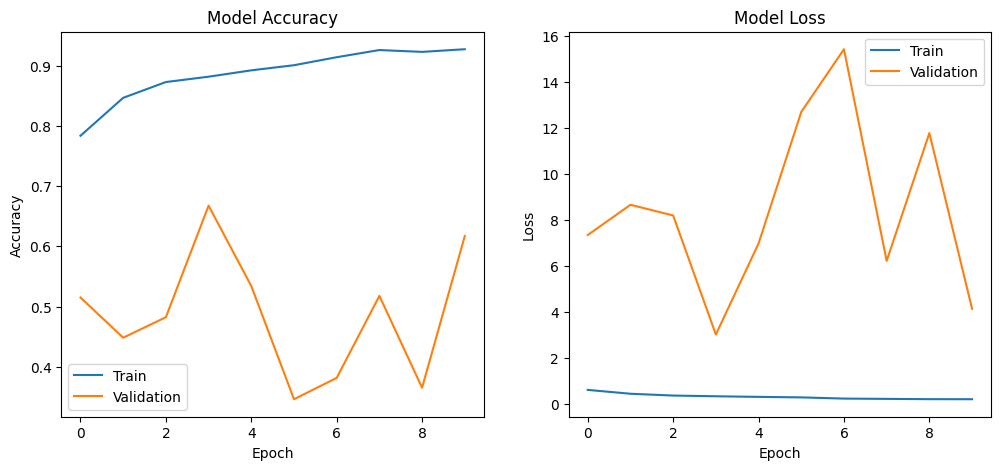

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()


In [ ]:
model.save("flower_classifier.h5")

print("Model Saved Successfully")


Model Saved Successfully


In [ ]:
img_path = tf.keras.utils.get_file(
    "test_flower.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
)

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

score = tf.nn.softmax(predictions[0])

print(
    "Predicted Class:",
    class_names[np.argmax(score)]
)

print(
    "Confidence:",
    round(100*np.max(score),2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: sunflowers
Confidence: 39.84 %
